In [33]:
import pandas as pd

df = pd.read_csv("data/cars_fuel_efficiency.csv")
print("Shape:", df.shape)
print()
print("Types:")
print(df.dtypes)
print()
print("Stats:")
print(df.describe())
print()
print("Пропуски:")
print(df.isna().sum())

Shape: (398, 9)

Types:
model                        object
year                          int64
cylinders                     int64
engine_litres               float64
power_hp                    float64
mass_kg                     float64
accel_0_100_s               float64
region                       object
fuel_efficiency_km_per_l    float64
dtype: object

Stats:
              year   cylinders  engine_litres    power_hp      mass_kg  \
count   398.000000  398.000000     398.000000  392.000000   398.000000   
mean   1976.010050    5.454774       3.169698  104.469388  1347.366834   
std       3.697627    1.701004       1.708993   38.491160   384.123755   
min    1970.000000    3.000000       1.110000   46.000000   732.000000   
25%    1973.000000    4.000000       1.705000   75.000000  1008.500000   
50%    1976.000000    4.000000       2.430000   93.500000  1271.500000   
75%    1979.000000    8.000000       4.290000  126.000000  1636.500000   
max    1982.000000    8.000000       7

In [34]:
print(df.isna().sum())

model                       0
year                        0
cylinders                   0
engine_litres               0
power_hp                    6
mass_kg                     0
accel_0_100_s               0
region                      0
fuel_efficiency_km_per_l    0
dtype: int64


In [35]:
df=df.dropna(subset=["power_hp"])
print('После dropna:', df.shape)
print('Пропуски теперь:', df.isna().sum().sum())

После dropna: (392, 9)
Пропуски теперь: 0


In [36]:
correlations=df.corr(numeric_only=True)['fuel_efficiency_km_per_l'].sort_values()
print(correlations)

mass_kg                    -0.832189
engine_litres              -0.805146
power_hp                   -0.778400
cylinders                  -0.777538
accel_0_100_s               0.423319
year                        0.580628
fuel_efficiency_km_per_l    1.000000
Name: fuel_efficiency_km_per_l, dtype: float64


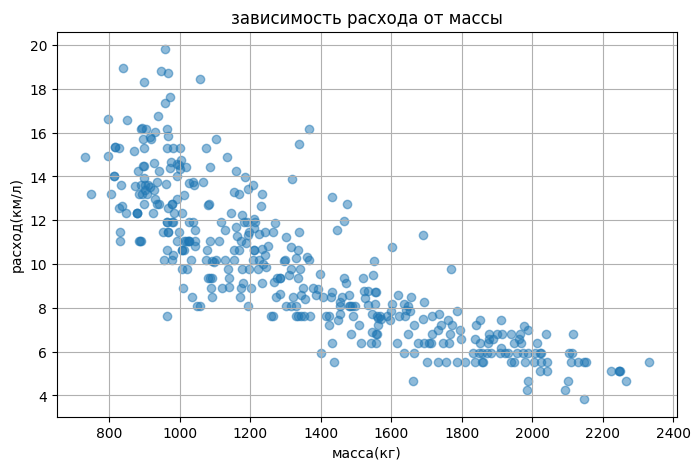

In [37]:
import matplotlib.pyplot as plt

best_feature = 'mass_kg'
X = df[[best_feature]]
Y = df['fuel_efficiency_km_per_l']

plt.figure(figsize=(8,5))
plt.scatter(X, Y, alpha=0.5)
plt.xlabel("масса(кг)")
plt.ylabel("расход(км/л)")
plt.title("зависимость расхода от массы")
plt.grid(True)
plt.show()

In [38]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, Y)

print("θ0 (intercept):", model.intercept_)
print("θ1 (slope):", model.coef_[0])

θ0 (intercept): 19.64697849141596
θ1 (slope): -0.007166625872637475


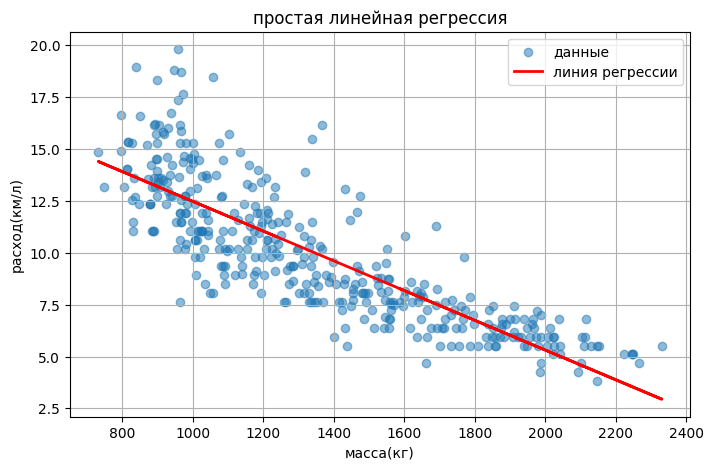

In [39]:
plt.figure(figsize=(8,5))
plt.scatter(X, Y, alpha=0.5, label="данные")
plt.plot(X, model.predict(X), color='red', linewidth=2, label="линия регрессии")
plt.xlabel("масса(кг)")
plt.ylabel("расход(км/л)")
plt.title("простая линейная регрессия")
plt.legend()
plt.grid(True)
plt.show()

In [40]:
new_value = 1500
prediction = model.predict([[new_value]])[0]
print(f"Масса {new_value} кг -> расход {prediction:.2f}км/л")

manual = model.intercept_ + model.coef_[0] * new_value
print(f"Проверка по формуле: {manual:.2f} км/л")

Масса 1500 кг -> расход 8.90км/л
Проверка по формуле: 8.90 км/л


/Users/meirim_ersultan/Desktop/ml_course/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


y = 19.65 - 0.0072 * mass_kg

In [41]:
from sklearn.model_selection import train_test_split

X = df[['mass_kg']]
Y = df["fuel_efficiency_km_per_l"]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=3039)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (313, 1)
Test: (79, 1)


In [42]:
from sklearn.linear_model import LinearRegression 

model = LinearRegression()
model.fit(X_train, Y_train)

print("b0:", model.intercept_)
print("b1:", model.coef_[0])

b0: 19.561925255700906
b1: -0.007082281936131131


In [43]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

Y_train_pred = model.predict(X_train)
Y_test_pred = model.predict(X_test)

print("=== TRAIN ===")
print("MAE: ", mean_absolute_error(Y_train, Y_train_pred))
print("MSE: ", mean_squared_error(Y_train, Y_train_pred))
print("RMSE:", np.sqrt(mean_squared_error(Y_train, Y_train_pred)))
print("R^2: ", r2_score(Y_train, Y_train_pred))

print("\n=== TEST ===")
print("MAE: ", mean_absolute_error(Y_test, Y_test_pred))
print("MSE: ", mean_squared_error(Y_test, Y_test_pred))
print("RMSE:", np.sqrt(mean_squared_error(Y_test, Y_test_pred)))
print("R²:  ", r2_score(Y_test, Y_test_pred))

=== TRAIN ===
MAE:  1.411901405102379
MSE:  3.467810795797613
RMSE: 1.862205895114075
R^2:  0.6844901939745189

=== TEST ===
MAE:  1.3192225651128309
MSE:  3.022600175234563
RMSE: 1.7385626750953107
R²:   0.7198281368940069


In [44]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model, X, Y, cv=5, scoring="r2")

print("CV R^2 scores:", cv_scores)
print("Mean R^2:     ", cv_scores.mean())
print("Std R^2:      ", cv_scores.std())

CV R^2 scores: [ 0.44921909  0.36183971  0.78595457  0.68915426 -0.71984508]
Mean R^2:      0.31326450834829433
Std R^2:       0.5390524301541043


In [45]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score


features_order = [
    "mass_kg",
    "engine_litres",
    "power_hp",
    "cylinders",
    "year",
    "accel_0_100_s",
]

Y = df["fuel_efficiency_km_per_l"]

In [46]:
results = []

for i in range(1, len(features_order) + 1):

    current_features = features_order[:i]
    X = df[current_features]
    

    model = LinearRegression()
    scores = cross_val_score(model, X, Y, cv=5, scoring="r2")
    

    results.append({
        "n_features": i,
        "features": ", ".join(current_features),
        "mean_r2": scores.mean(),
        "std_r2": scores.std(),
    })
    

    print(f"{i} feature(s) | mean R² = {scores.mean():.4f} | std = {scores.std():.4f}")

1 feature(s) | mean R² = 0.3133 | std = 0.5391
2 feature(s) | mean R² = 0.3253 | std = 0.5227
3 feature(s) | mean R² = 0.3285 | std = 0.5057
4 feature(s) | mean R² = 0.3298 | std = 0.5028
5 feature(s) | mean R² = 0.5754 | std = 0.2261
6 feature(s) | mean R² = 0.5709 | std = 0.2307


In [47]:
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

 n_features                                                         features  mean_r2   std_r2
          1                                                          mass_kg 0.313265 0.539052
          2                                           mass_kg, engine_litres 0.325333 0.522690
          3                                 mass_kg, engine_litres, power_hp 0.328538 0.505726
          4                      mass_kg, engine_litres, power_hp, cylinders 0.329805 0.502771
          5                mass_kg, engine_litres, power_hp, cylinders, year 0.575424 0.226143
          6 mass_kg, engine_litres, power_hp, cylinders, year, accel_0_100_s 0.570935 0.230688


In [48]:
print("\n=== Таблица для лабы ===\n")
print(f"| Features used | Mean test R² (5-fold) |")
print(f"|---|---|")
print(f"| {features_order[0]} | {results[0]['mean_r2']:.4f} |")
print(f"| + {features_order[1]} | {results[1]['mean_r2']:.4f} |")
print(f"| + all remaining numeric features | {results[-1]['mean_r2']:.4f} |")


=== Таблица для лабы ===

| Features used | Mean test R² (5-fold) |
|---|---|
| mass_kg | 0.3133 |
| + engine_litres | 0.3253 |
| + all remaining numeric features | 0.5709 |


In [49]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

# Лучший одиночный признак из Шага 3
X = df[["mass_kg"]]
Y = df["fuel_efficiency_km_per_l"]

In [50]:
degrees = [1, 2, 3, 4, 5]
results = []

for degree in degrees:
    pipe = make_pipeline(
        StandardScaler(),
        PolynomialFeatures(degree=degree, include_bias=False),
        LinearRegression(),
    )
    
    pipe.fit(X, y)
    train_r2 = pipe.score(X, Y)
    

    cv_scores = cross_val_score(pipe, X, Y, cv=5, scoring="r2")
    test_r2_mean = cv_scores.mean()
    test_r2_std = cv_scores.std()
    
    results.append({
        "degree": degree,
        "train_r2": train_r2,
        "test_r2_mean": test_r2_mean,
        "test_r2_std": test_r2_std,
    })
    
    print(f"Degree {degree}: train R² = {train_r2:.4f}, "
          f"test R² = {test_r2_mean:.4f} (±{test_r2_std:.4f})")

Degree 1: train R² = 0.6925, test R² = 0.3133 (±0.5391)
Degree 2: train R² = 0.7151, test R² = 0.3552 (±0.5395)
Degree 3: train R² = 0.7151, test R² = 0.3445 (±0.5565)
Degree 4: train R² = 0.7154, test R² = 0.3401 (±0.5580)
Degree 5: train R² = 0.7160, test R² = 0.3373 (±0.5575)


In [52]:
import pandas as pd

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

 degree  train_r2  test_r2_mean  test_r2_std
      1  0.692538      0.313265     0.539052
      2  0.715055      0.355173     0.539482
      3  0.715056      0.344470     0.556462
      4  0.715383      0.340093     0.557968
      5  0.715996      0.337316     0.557481


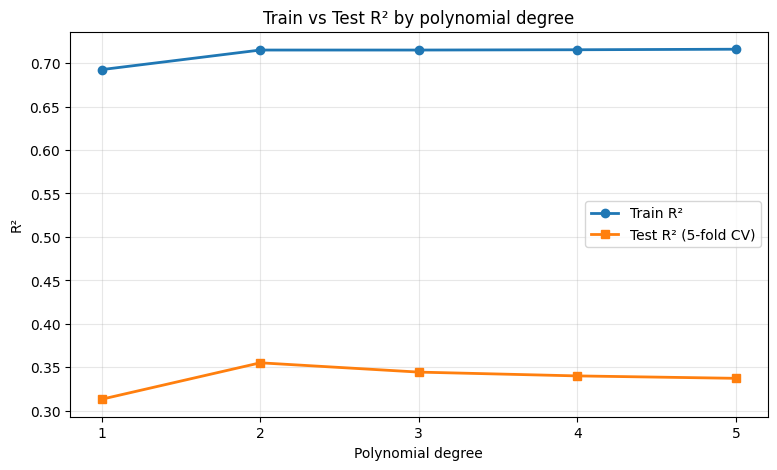

In [53]:
plt.figure(figsize=(9, 5))

plt.plot(results_df["degree"], results_df["train_r2"],
         marker="o", label="Train R²", linewidth=2)

plt.plot(results_df["degree"], results_df["test_r2_mean"],
         marker="s", label="Test R² (5-fold CV)", linewidth=2)

plt.xlabel("Polynomial degree")
plt.ylabel("R²")
plt.title("Train vs Test R² by polynomial degree")
plt.xticks(degrees)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [54]:
best_idx = results_df["test_r2_mean"].idxmax()
best_degree = results_df.loc[best_idx, "degree"]
best_test_r2 = results_df.loc[best_idx, "test_r2_mean"]
best_train_r2 = results_df.loc[best_idx, "train_r2"]

print(f"Оптимальная степень: {best_degree}")
print(f"На этой степени: train R² = {best_train_r2:.4f}, test R² = {best_test_r2:.4f}")

Оптимальная степень: 2
На этой степени: train R² = 0.7151, test R² = 0.3552
